In [3]:
from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import mesh, fem
from dolfinx.fem.petsc import assemble_vector, assemble_matrix, apply_lifting, set_bc
import numpy as np
import ufl
import basix.ufl


# 1. DOMAIN & MESH
Lx, Ly, Lz = 6.096, 6.096, 0.1058e-03
Nx, Ny = 4, 4 

domain = mesh.create_rectangle(
    MPI.COMM_WORLD, [[0.0, 0.0], [Lx, Ly]], [Nx, Ny],
    cell_type=mesh.CellType.triangle
)

# 2. ELEMENTS & FUNCTION SPACE
element = basix.ufl.element("Lagrange", domain.basix_cell(), 1, shape=(3,))
V = fem.functionspace(domain, element)
u, v, du = fem.Function(V, name="u"), ufl.TestFunction(V), ufl.TrialFunction(V)


# 3. BOUNDARY CONDITIONS
def on_boundary(x):
    return np.logical_or.reduce((np.isclose(x[0], 0.0), np.isclose(x[0], Lx),
                                np.isclose(x[1], 0.0), np.isclose(x[1], Ly)))
boundary_dofs = fem.locate_dofs_geometrical(V, on_boundary)
bc = fem.dirichletbc(np.array([0.0, 0.0, 0.0], dtype=PETSc.ScalarType), boundary_dofs, V)


# 4. MATERIAL & KINEMATICS
E_mod, nu = 206842.719e6, 0.3
delta, G = 1.0 - nu**2, E_mod / (2 * (1 + nu))
C_voigt = ufl.as_matrix([[E_mod/delta, nu*E_mod/delta, 0], 
                         [nu*E_mod/delta, E_mod/delta, 0], 
                         [0, 0, G]])

def grad_3d(u):
    g = ufl.grad(u)
    return ufl.as_tensor([[g[0,0], g[0,1], 0], 
                          [g[1,0], g[1,1], 0], 
                          [g[2,0], g[2,1], 0]])

I = ufl.Identity(3)
F_kin = I + grad_3d(u)

# J (Area change ratio) is critical for Cauchy pre-stress flexibility(not used here, check if J is to be used)
# We take the determinant of the 2x2 in-plane part of the deformation gradient
J = ufl.det(ufl.as_matrix([
    [F_kin[0,0], F_kin[0,1]],
    [F_kin[1,0], F_kin[1,1]]
]))

eps_gl = 0.5 * (F_kin.T * F_kin - I)

# Global Cartesian basis (no rotation)
eps_fib = ufl.as_vector([eps_gl[0, 0], eps_gl[1, 1],  eps_gl[0, 1]])

#Prestress(uniform in both directions)
sig0_voigt = ufl.as_vector([551.581e6, 551.581e6, 0.0])
t = fem.Constant(domain, PETSc.ScalarType(Lz))
dx_mesh = ufl.Measure("dx", domain=domain)



# 5. ENERGY & WEAK FORM
# Total Potential Energy: (Stiffness Part) + (Cauchy Pre-stress Part / J)J not used here, tries to use
pi_total = t * (0.5 * ufl.dot(eps_fib, C_voigt * eps_fib) + 
                ufl.dot(sig0_voigt, eps_fib) ) * dx_mesh


F_ufl = ufl.derivative(pi_total, u, v)
J_ufl = ufl.derivative(F_ufl, u, du)

F_form = fem.form(F_ufl)
J_form = fem.form(J_ufl)


# 6. LOAD STEPPING CONSTANTS (to initiate certain value of u, does not work to give the load at once since Jacobian becomes 0, or we can use the solver twice)

load_factor = fem.Constant(domain, PETSc.ScalarType(0.0))
total_load = -44.482216e3


# Find Point Load DOF
dof_coords = V.tabulate_dof_coordinates()
target_pos = np.array([Lx/2, Ly/2, 0.0])
node_idx = np.argmin(np.linalg.norm(dof_coords - target_pos, axis=1))
load_dof = node_idx * 3 + 2



# 7. SNES ASSEMBLY FUNCTIONS
def assemble_residual(snes, x, b):
    x.copy(u.x.petsc_vec)
    u.x.petsc_vec.ghostUpdate(PETSc.InsertMode.INSERT, PETSc.ScatterMode.FORWARD)
    
    with b.localForm() as b_loc: 
        b_loc.set(0.0) # FIXED: Name corrected from b_local to b_loc
        
    assemble_vector(b, F_form)
    
    current_load = total_load * float(load_factor)
    with b.localForm() as b_loc:
        if load_dof < len(b_loc.array):
            b_loc.array[load_dof] -= current_load
            
    apply_lifting(b, [J_form], [[bc]], [x], -1.0)
    b.ghostUpdate(PETSc.InsertMode.ADD, PETSc.ScatterMode.REVERSE)
    set_bc(b, [bc], x, -1.0)

def assemble_jacobian(snes, x, A, P):
    A.zeroEntries()
    assemble_matrix(A, J_form, bcs=[bc])
    A.assemble()


    # 8. SOLVER SETUP (MUMPS)
A_mat, b_vec = fem.petsc.create_matrix(J_form), u.x.petsc_vec.duplicate()
snes = PETSc.SNES().create(domain.comm)
snes.setFunction(assemble_residual, b_vec)
snes.setJacobian(assemble_jacobian, A_mat)

opts = PETSc.Options()
prefix = "m_"
snes.setOptionsPrefix(prefix)
petsc_opts = {
    "snes_type": "newtonls", 
    "snes_linesearch_type": "bt",
    "ksp_type": "preonly", 
    "pc_type": "lu", 
    "pc_factor_mat_solver_type": "mumps",
    "snes_atol": 1e-12, 
    "snes_rtol": 1e-12,
    "snes_max_it": 100000,  # <--- Add or change this value (default is usually 50)
}

for k, v in petsc_opts.items(): opts[f"{prefix}{k}"] = v
snes.setFromOptions()

# 9. EXECUTION
# Curvature nudge to activate geometric stiffness
u.x.array[2::3] = 1e-3 
u.x.scatter_forward()

num_steps = 10 # give minimum value 10 as load cannot be given at once, need to check why

print(f"Total DOFs: {V.dofmap.index_map.size_global * V.dofmap.index_map_bs}")

for val in np.linspace(0.1, 1.0, num_steps):
    load_factor.value = val
    snes.solve(None, u.x.petsc_vec)
    u.x.scatter_forward()
    print(f"Factor {val:.1f} | Max u3: {u.x.array.reshape(-1,3)[:,2].min():.6e} m")

print(f"\nFinal Convergence Reason: {snes.getConvergedReason()}")


#Check convergence reason also, and more details on the solver
#Need to check the number of mesh required (Doesn't converge when the number of meshes increases a lot)

Total DOFs: 75
Factor 0.1 | Max u3: -4.279369e-02 m
Factor 0.2 | Max u3: -5.317336e-02 m
Factor 0.3 | Max u3: -7.479121e-02 m
Factor 0.4 | Max u3: -9.332342e-02 m
Factor 0.5 | Max u3: -1.094339e-01 m
Factor 0.6 | Max u3: -1.236661e-01 m
Factor 0.7 | Max u3: -1.364217e-01 m
Factor 0.8 | Max u3: -1.479936e-01 m
Factor 0.9 | Max u3: -1.585981e-01 m
Factor 1.0 | Max u3: -1.683983e-01 m

Final Convergence Reason: 4


Max u3 (downward): -1.683983e-01 m
Max u3 (upward):   0.000000e+00 m
Max |u1|:          9.815018e-04 m
Max |u2|:          9.815018e-04 m


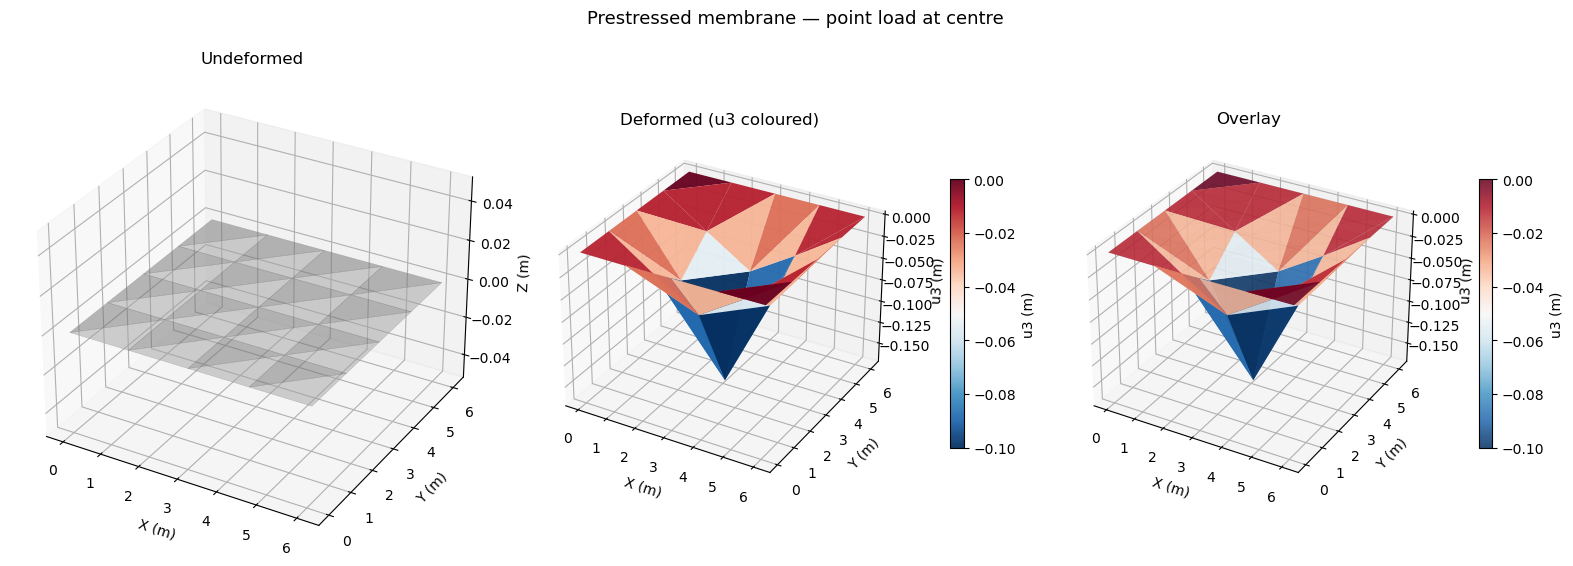

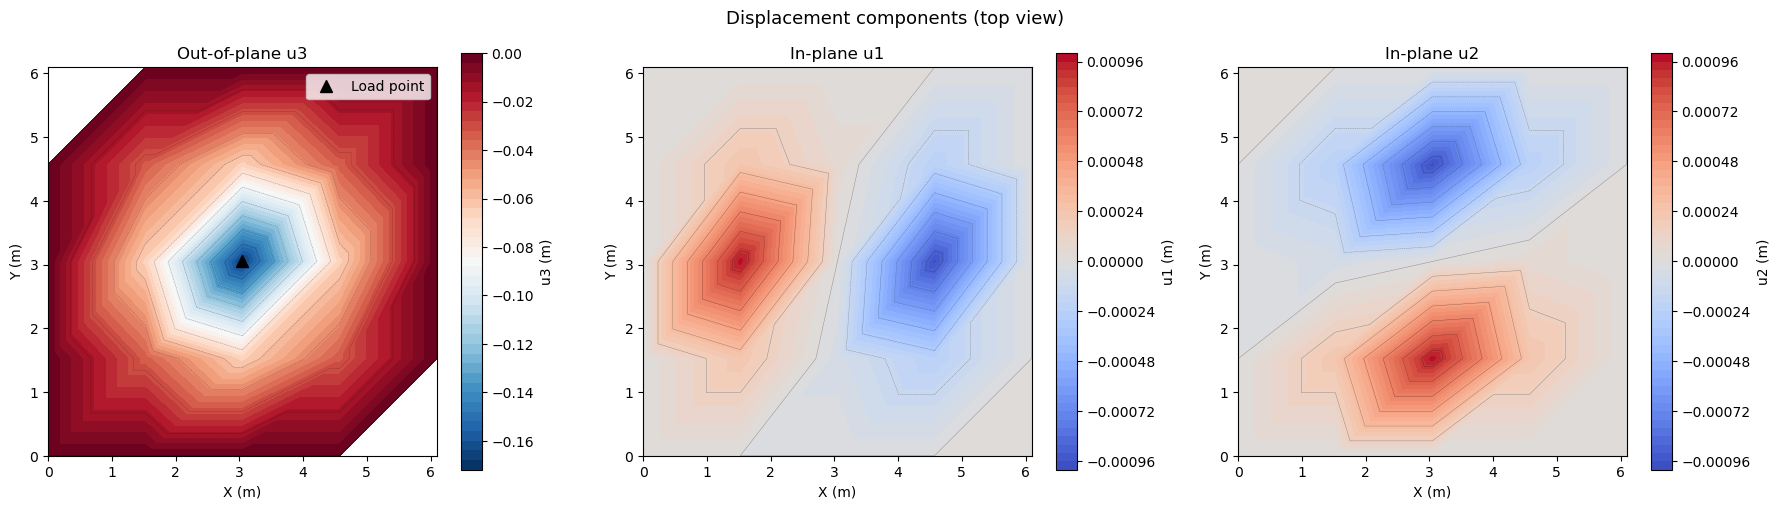

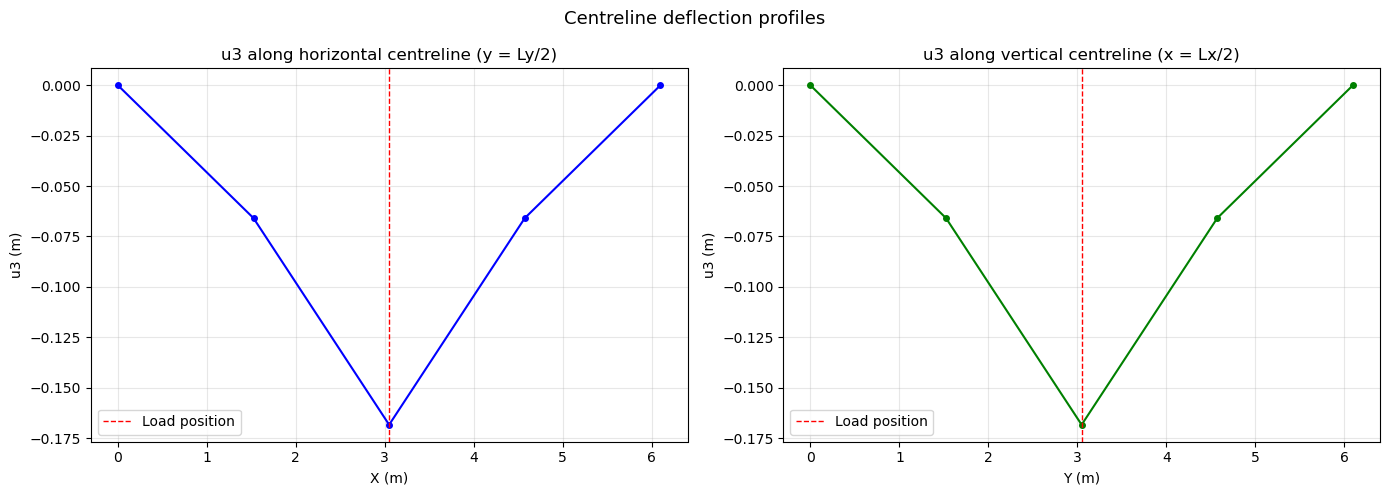

In [2]:
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np

# ----------------------------
# 1. Map DOFs to geometry nodes
# ----------------------------
coords    = domain.geometry.x
x_coords  = coords[:, 0]
y_coords  = coords[:, 1]
num_nodes = coords.shape[0]

dof_coords = V.tabulate_dof_coordinates()   # (num_dof_nodes, 3)
u_all      = u.x.array.real.reshape(-1, 3)  # (num_dof_nodes, 3)

# Build coordinate -> dof index lookup
dof_map = {}
for i, c in enumerate(dof_coords):
    key = (round(c[0], 8), round(c[1], 8))
    dof_map[key] = i

u1 = np.zeros(num_nodes)
u2 = np.zeros(num_nodes)
u3 = np.zeros(num_nodes)

for j, c in enumerate(coords):
    key = (round(c[0], 8), round(c[1], 8))
    idx = dof_map.get(key)
    if idx is not None:
        u1[j] = u_all[idx, 0]
        u2[j] = u_all[idx, 1]
        u3[j] = u_all[idx, 2]

# Deformed coordinates
x_def = x_coords + u1
y_def = y_coords + u2
z_def = u3

# ----------------------------
# 2. Build triangulation
# ----------------------------
domain.topology.create_connectivity(2, 0)
conn      = domain.topology.connectivity(2, 0)
triangles = np.array([conn.links(i) for i in range(conn.num_nodes)])
tri_orig  = mtri.Triangulation(x_coords, y_coords, triangles)
tri_def   = mtri.Triangulation(x_def,    y_def,    triangles)

# ----------------------------
# 3. Summary statistics
# ----------------------------
print(f"Max u3 (downward): {u3.min():.6e} m")
print(f"Max u3 (upward):   {u3.max():.6e} m")
print(f"Max |u1|:          {np.abs(u1).max():.6e} m")
print(f"Max |u2|:          {np.abs(u2).max():.6e} m")

# ----------------------------
# 4. Plot 1 — 3D deformed surface
# ----------------------------
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 6))

# Undeformed
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(x_coords, y_coords, np.zeros_like(x_coords),
                 triangles=triangles, color='lightgray',
                 alpha=0.5, edgecolor='gray', linewidth=0.3)
ax1.set_title("Undeformed")
ax1.set_xlabel("X (m)"); ax1.set_ylabel("Y (m)"); ax1.set_zlabel("Z (m)")

# Deformed — coloured by u3
ax2 = fig.add_subplot(132, projection='3d')
surf = ax2.plot_trisurf(x_def, y_def, z_def,
                        triangles=triangles,
                        cmap='RdBu_r', edgecolor='none', alpha=0.95)
fig.colorbar(surf, ax=ax2, label='u3 (m)', shrink=0.5, pad=0.1)
ax2.set_title("Deformed (u3 coloured)")
ax2.set_xlabel("X (m)"); ax2.set_ylabel("Y (m)"); ax2.set_zlabel("u3 (m)")

# Overlay — undeformed (wireframe) + deformed (surface)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(x_coords, y_coords, np.zeros_like(x_coords),
                 triangles=triangles, color='lightgray',
                 alpha=0.2, edgecolor='gray', linewidth=0.3)
surf2 = ax3.plot_trisurf(x_def, y_def, z_def,
                          triangles=triangles,
                          cmap='RdBu_r', edgecolor='none', alpha=0.85)
fig.colorbar(surf2, ax=ax3, label='u3 (m)', shrink=0.5, pad=0.1)
ax3.set_title("Overlay")
ax3.set_xlabel("X (m)"); ax3.set_ylabel("Y (m)"); ax3.set_zlabel("u3 (m)")

plt.suptitle("Prestressed membrane — point load at centre", fontsize=13)
plt.tight_layout()
plt.savefig("membrane_3d.png", dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# 5. Plot 2 — top-down contour maps
# ----------------------------
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))

# u3 contour
tcf0 = axes[0].tricontourf(tri_orig, u3, levels=50, cmap='RdBu_r')
axes[0].tricontour(tri_orig, u3, levels=15,
                   colors='k', linewidths=0.3, alpha=0.4)
fig2.colorbar(tcf0, ax=axes[0], label='u3 (m)')
axes[0].set_title("Out-of-plane u3")
axes[0].set_xlabel("X (m)"); axes[0].set_ylabel("Y (m)")
axes[0].set_aspect('equal')
# Mark load point
axes[0].plot(Lx/2, Ly/2, 'k^', markersize=8, label='Load point')
axes[0].legend()

# u1 contour
tcf1 = axes[1].tricontourf(tri_orig, u1, levels=50, cmap='coolwarm')
axes[1].tricontour(tri_orig, u1, levels=15,
                   colors='k', linewidths=0.3, alpha=0.4)
fig2.colorbar(tcf1, ax=axes[1], label='u1 (m)')
axes[1].set_title("In-plane u1")
axes[1].set_xlabel("X (m)"); axes[1].set_ylabel("Y (m)")
axes[1].set_aspect('equal')

# u2 contour
tcf2 = axes[2].tricontourf(tri_orig, u2, levels=50, cmap='coolwarm')
axes[2].tricontour(tri_orig, u2, levels=15,
                   colors='k', linewidths=0.3, alpha=0.4)
fig2.colorbar(tcf2, ax=axes[2], label='u2 (m)')
axes[2].set_title("In-plane u2")
axes[2].set_xlabel("X (m)"); axes[2].set_ylabel("Y (m)")
axes[2].set_aspect('equal')

plt.suptitle("Displacement components (top view)", fontsize=13)
plt.tight_layout()
plt.savefig("membrane_contours.png", dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# 6. Plot 3 — centreline cross-sections
# ----------------------------
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal centreline: y ≈ Ly/2
tol      = Ly / (2 * Ny)
mid_mask = np.abs(y_coords - Ly/2) < tol
x_line   = x_coords[mid_mask]
u3_xline = u3[mid_mask]
sort_idx = np.argsort(x_line)

axes3[0].plot(x_line[sort_idx], u3_xline[sort_idx],
              'b-o', markersize=4, linewidth=1.5)
axes3[0].axvline(Lx/2, color='r', linestyle='--',
                 linewidth=1, label='Load position')
axes3[0].set_xlabel("X (m)")
axes3[0].set_ylabel("u3 (m)")
axes3[0].set_title("u3 along horizontal centreline (y = Ly/2)")
axes3[0].legend()
axes3[0].grid(True, alpha=0.3)

# Vertical centreline: x ≈ Lx/2
mid_maskY = np.abs(x_coords - Lx/2) < tol
y_line    = y_coords[mid_maskY]
u3_yline  = u3[mid_maskY]
sort_idxY = np.argsort(y_line)

axes3[1].plot(y_line[sort_idxY], u3_yline[sort_idxY],
              'g-o', markersize=4, linewidth=1.5)
axes3[1].axvline(Ly/2, color='r', linestyle='--',
                 linewidth=1, label='Load position')
axes3[1].set_xlabel("Y (m)")
axes3[1].set_ylabel("u3 (m)")
axes3[1].set_title("u3 along vertical centreline (x = Lx/2)")
axes3[1].legend()
axes3[1].grid(True, alpha=0.3)

plt.suptitle("Centreline deflection profiles", fontsize=13)
plt.tight_layout()
plt.savefig("membrane_centrelines.png", dpi=150, bbox_inches='tight')
plt.show()

# ----------------------------
# 7. Plot 4 — load stepping history
# ----------------------------
# Re-run with history tracking — add this BEFORE the load stepping loop:
#
#   load_factors = []
#   u3_centre    = []
#
# Inside the loop after solve:
#   load_factors.append(val)
#   u_arr = u.x.array.reshape(-1, 3)
#   u3_centre.append(u_arr[node_idx, 2])
#
# Then plot:

# (Uncomment if you re-run with history tracking)
# fig4, ax4 = plt.subplots(figsize=(8, 5))
# ax4.plot(np.array(load_factors) * abs(total_load) / 1e3,
#          np.array(u3_centre) * 1e3,
#          'b-o', markersize=5)
# ax4.set_xlabel("Applied load (kN)")
# ax4.set_ylabel("u3 at centre (mm)")
# ax4.set_title("Load-deflection curve")
# ax4.grid(True, alpha=0.3)
# plt.tight_layout()
# plt.savefig("load_deflection.png", dpi=150)
# plt.show()